# 01 — Black-Scholes Greeks Visualization

This notebook visualizes how each Greek changes with respect to key inputs:

1. **Greeks vs Spot Price** — Delta, Gamma, Vega, Theta, Rho as S varies
2. **Greeks vs Time to Maturity** — Theta decay curve; how Greeks evolve as expiry approaches
3. **Delta & Gamma across strikes** — multi-expiry comparison (skew + convexity)
4. **Vega heatmap** — sensitivity over the (S, T) grid

All parameters reference a **SPY-like ATM call** as the base case:

| Parameter | Value |
|-----------|-------|
| S (spot)  | 700   |
| K (strike)| 700   |
| r         | 3.6%  |
| q         | 1.3%  |
| σ         | 20%   |
| T         | 0.5 yr |

## 1. Setup

In [1]:
import os, sys
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from models.bs_model import bs_price, bs_delta, bs_gamma, bs_vega, bs_theta, bs_rho, bs_greeks

OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── Base parameters (SPY-like ATM) ─────────────────────────────────────────────
S0    = 700.0   # spot
K0    = 700.0   # strike
T0    = 0.5     # time to maturity (years)
r0    = 0.036   # risk-free rate
q0    = 0.013   # dividend yield
sig0  = 0.20    # implied vol

# Confirm base-case Greeks
print("Base-case ATM call Greeks:")
g = bs_greeks(S0, K0, T0, r0, sig0, q0, "call")
for k, v in g.items():
    print(f"  {k:6s}: {v:.6f}")

Base-case ATM call Greeks:
  price : 43.085197
  delta : 0.556787
  gamma : 0.003958
  vega  : 193.932849
  theta : -46.199768
  rho   : 173.332732


## 2. Greeks vs Spot Price

We sweep S from deep OTM to deep ITM, holding everything else fixed.  
Both **call** and **put** are shown side-by-side.

Key observations to look for:
- **Delta**: S-shaped, bounded in [0,1] for calls / [-1,0] for puts; = 0.5 ATM
- **Gamma**: bell-shaped, peaks ATM — largest when hedging cost is highest
- **Vega**: also bell-shaped and ATM-peaked — same shape as Gamma (both ∝ n(d₁))
- **Theta**: most negative near ATM — time decay is fastest there
- **Rho**: monotone — higher S → higher call price → more rate sensitivity

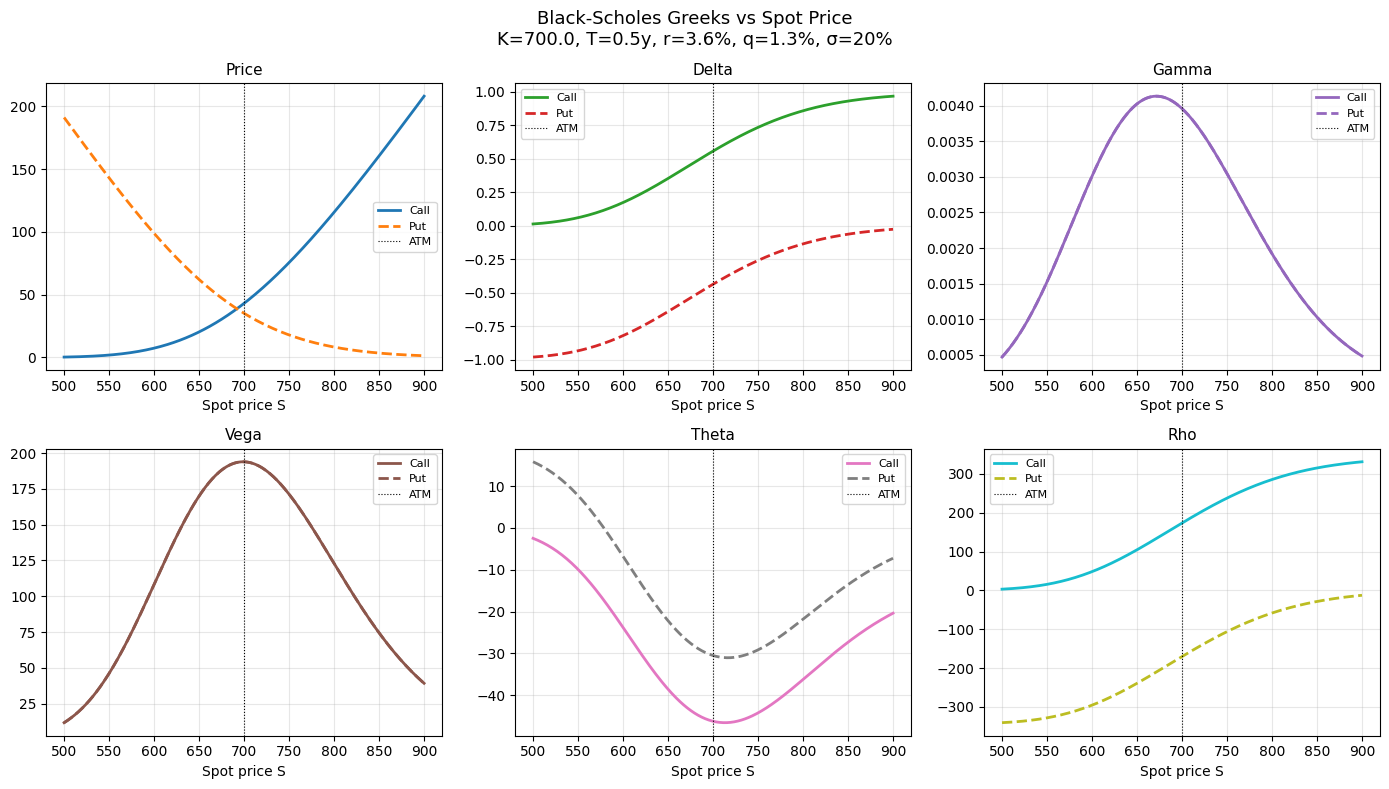

Saved outputs/greeks_vs_spot.png


In [2]:
S_range = np.linspace(500, 900, 300)

def greeks_over_S(option_type):
    out = {"price": [], "delta": [], "gamma": [], "vega": [], "theta": [], "rho": []}
    for S in S_range:
        g = bs_greeks(S, K0, T0, r0, sig0, q0, option_type)
        for key in out:
            out[key].append(g[key])
    return {k: np.array(v) for k, v in out.items()}

call_g = greeks_over_S("call")
put_g  = greeks_over_S("put")

greek_meta = [
    ("price", "Price",  "tab:blue",   "tab:orange"),
    ("delta", "Delta",  "tab:green",  "tab:red"),
    ("gamma", "Gamma",  "tab:purple", "tab:purple"),
    ("vega",  "Vega",   "tab:brown",  "tab:brown"),
    ("theta", "Theta",  "tab:pink",   "tab:gray"),
    ("rho",   "Rho",    "tab:cyan",   "tab:olive"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Black-Scholes Greeks vs Spot Price\n"
             f"K={K0}, T={T0}y, r={r0:.1%}, q={q0:.1%}, σ={sig0:.0%}",
             fontsize=13)

for ax, (key, label, cc, pc) in zip(axes.flat, greek_meta):
    ax.plot(S_range, call_g[key], color=cc, lw=2, label="Call")
    ax.plot(S_range, put_g[key],  color=pc, lw=2, ls="--", label="Put")
    ax.axvline(K0, color="black", lw=0.8, ls=":", label="ATM")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Spot price S")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "greeks_vs_spot.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved outputs/greeks_vs_spot.png")

## 3. Greeks vs Time to Maturity (Theta Decay)

Fix S = K (ATM) and sweep T from 2 years down to near-zero.  
Three moneyness levels are overlaid: **ITM** (S=770), **ATM** (S=700), **OTM** (S=630).

Key observations:
- **Theta** accelerates toward expiry (non-linear decay — "theta burn")
- **Gamma** spikes at expiry for ATM options — binary-like payoff
- **Vega** shrinks as T → 0 — vol has less time to matter
- **Delta** of ATM option converges to 0.5 regardless of T (approx.)

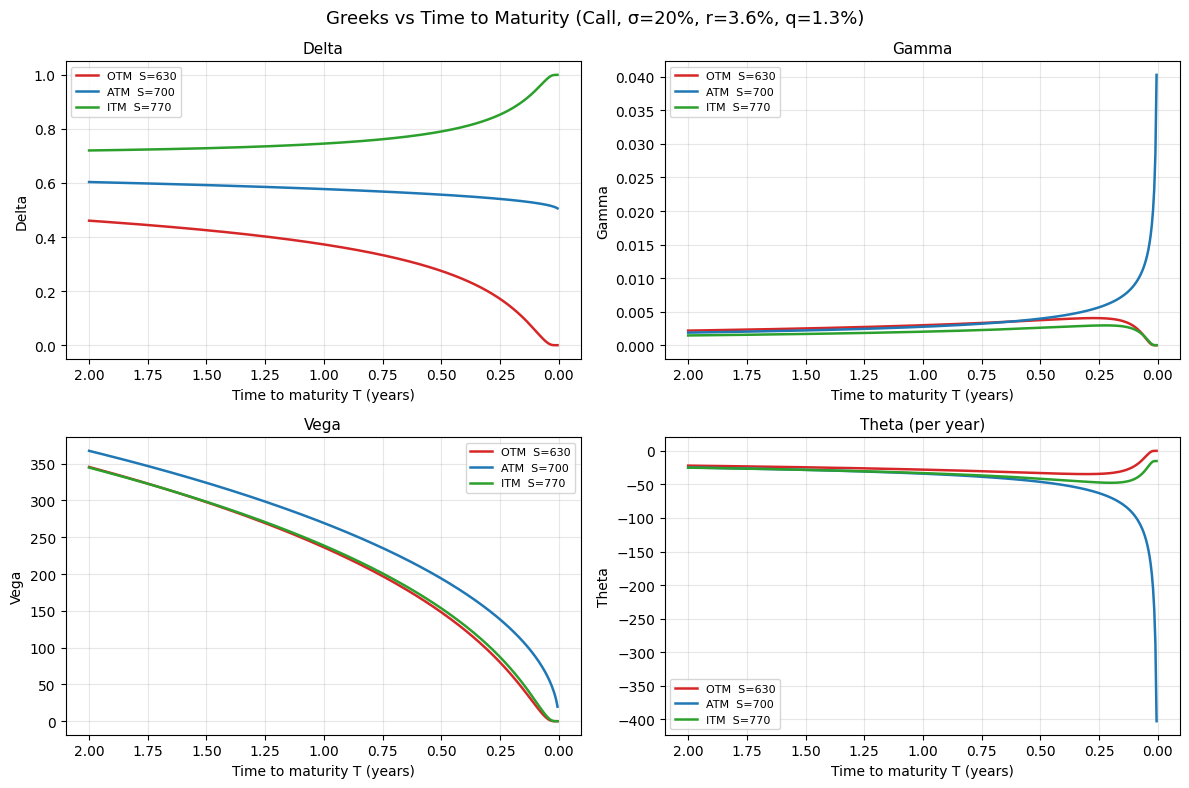

Saved outputs/greeks_vs_ttm.png


In [3]:
T_range = np.linspace(0.005, 2.0, 400)  # 2 years down to ~2 days

moneyness_cases = [
    (630, "OTM  S=630", "tab:red"),
    (700, "ATM  S=700", "tab:blue"),
    (770, "ITM  S=770", "tab:green"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Greeks vs Time to Maturity (Call, σ=20%, r=3.6%, q=1.3%)", fontsize=13)

greek_keys = [("delta", "Delta"), ("gamma", "Gamma"),
              ("vega",  "Vega"),  ("theta", "Theta (per year)")]

for ax, (key, label) in zip(axes.flat, greek_keys):
    for S_fix, name, color in moneyness_cases:
        vals = np.array([
            bs_greeks(S_fix, K0, T, r0, sig0, q0, "call")[key]
            for T in T_range
        ])
        ax.plot(T_range, vals, color=color, lw=1.8, label=name)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Time to maturity T (years)")
    ax.invert_xaxis()   # left = far expiry, right = near expiry
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[0, 0].set_ylabel("Delta")
axes[0, 1].set_ylabel("Gamma")
axes[1, 0].set_ylabel("Vega")
axes[1, 1].set_ylabel("Theta")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "greeks_vs_ttm.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved outputs/greeks_vs_ttm.png")

## 4. Delta & Gamma across Strikes — Multi-Expiry Comparison

For a fixed spot S=700, sweep strikes K ∈ [560, 840] across **five expiries**.

This shows:
- How Delta transitions from 1 → 0 (call) shifts with maturity
- How Gamma's ATM peak **sharpens** as expiry approaches (pin risk)

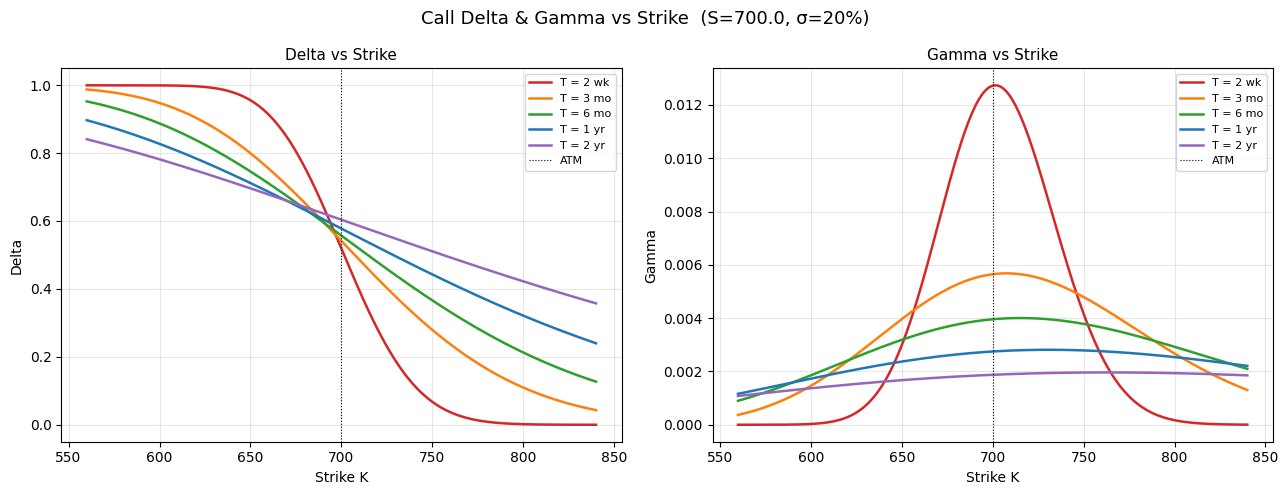

Saved outputs/delta_gamma_vs_strike.png


In [4]:
K_range = np.linspace(560, 840, 300)

expiries = [
    (0.05,  "T = 2 wk",  "tab:red"),
    (0.25,  "T = 3 mo",  "tab:orange"),
    (0.5,   "T = 6 mo",  "tab:green"),
    (1.0,   "T = 1 yr",  "tab:blue"),
    (2.0,   "T = 2 yr",  "tab:purple"),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Call Delta & Gamma vs Strike  (S={S0}, σ={sig0:.0%})", fontsize=13)

for T_fix, label, color in expiries:
    deltas = np.array([bs_delta(S0, K, T_fix, r0, sig0, q0, "call") for K in K_range])
    gammas = np.array([bs_gamma(S0, K, T_fix, r0, sig0, q0)         for K in K_range])
    ax1.plot(K_range, deltas, color=color, lw=1.8, label=label)
    ax2.plot(K_range, gammas, color=color, lw=1.8, label=label)

for ax, title, ylabel in [
    (ax1, "Delta vs Strike", "Delta"),
    (ax2, "Gamma vs Strike", "Gamma"),
]:
    ax.axvline(S0, color="black", lw=0.8, ls=":", label="ATM")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Strike K")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "delta_gamma_vs_strike.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved outputs/delta_gamma_vs_strike.png")

## 5. Vega Heatmap over (Spot, Time-to-Maturity)

Vega tells us how sensitive the option price is to a 1-unit move in σ.  
The heatmap reveals the **vol-sensitive region** of the (S, T) space:

- Vega peaks near ATM and at longer maturities
- Deep OTM/ITM or near-expiry options have very low Vega → vol changes matter little

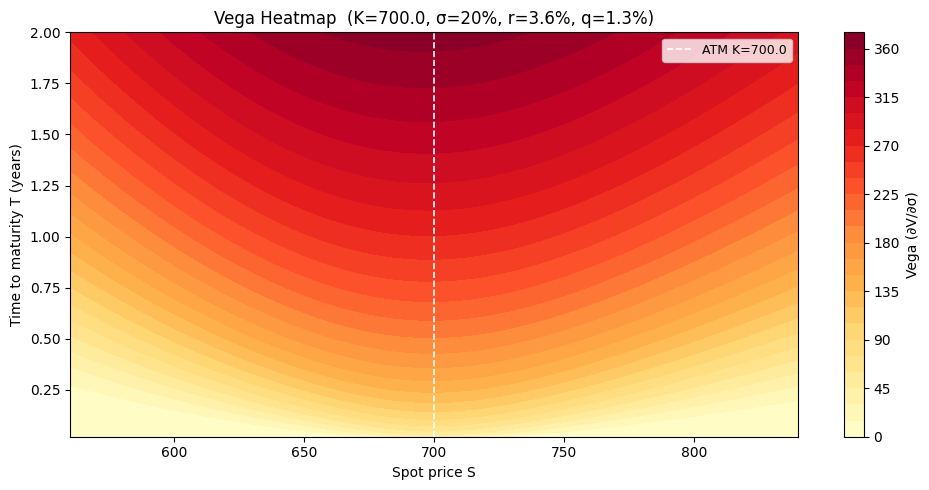

Saved outputs/vega_heatmap.png


In [5]:
S_grid = np.linspace(560, 840, 120)
T_grid = np.linspace(0.02, 2.0, 100)

SS, TT = np.meshgrid(S_grid, T_grid)
vega_map = np.vectorize(lambda s, t: bs_vega(s, K0, t, r0, sig0, q0))(SS, TT)

fig, ax = plt.subplots(figsize=(10, 5))
cf = ax.contourf(SS, TT, vega_map, levels=30, cmap="YlOrRd")
fig.colorbar(cf, ax=ax, label="Vega (∂V/∂σ)")
ax.axvline(K0, color="white", lw=1.2, ls="--", label=f"ATM K={K0}")
ax.set_xlabel("Spot price S")
ax.set_ylabel("Time to maturity T (years)")
ax.set_title(f"Vega Heatmap  (K={K0}, σ={sig0:.0%}, r={r0:.1%}, q={q0:.1%})", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, "vega_heatmap.png"), dpi=120, bbox_inches="tight")
plt.show()
print("Saved outputs/vega_heatmap.png")

## 6. Greeks Sensitivity Summary Table

Print a compact table of all Greeks at several (S, T) combinations to sanity-check magnitudes.

In [6]:
import pandas as pd

cases = [
    (630, 0.5,  "OTM, 6mo"),
    (700, 0.05, "ATM, 2wk"),
    (700, 0.5,  "ATM, 6mo"),
    (700, 1.0,  "ATM, 1yr"),
    (700, 2.0,  "ATM, 2yr"),
    (770, 0.5,  "ITM, 6mo"),
]

rows = []
for S, T, desc in cases:
    g = bs_greeks(S, K0, T, r0, sig0, q0, "call")
    rows.append({"Case": desc, "S": S, "T": T, **g})

df_summary = pd.DataFrame(rows).set_index("Case")
df_summary = df_summary.round(4)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
df_summary

,S,T,price,delta,gamma,vega,theta,rho
Case,,,,,,,,
"OTM, 6mo",630,0.5000,14.0698,0.2748,0.0037,148.1008,-33.0956,79.5284
"ATM, 2wk",700,0.0500,12.8787,0.5188,0.0127,62.3317,-132.5530,17.5153
"ATM, 6mo",700,0.5000,43.0852,0.5568,0.0040,193.9328,-46.1998,173.3327
"ATM, 1yr",700,1.0000,62.6266,0.5776,0.0027,269.3548,-33.9796,341.6647
"ATM, 2yr",700,2.0000,91.2935,0.6036,0.0019,367.4144,-24.8015,662.3957
"ITM, 6mo",770,0.5000,90.8102,0.7904,0.0026,153.4328,-41.4160,258.9126
